# Imports

In [27]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

from imblearn.over_sampling    import SMOTE
from imblearn.pipeline         import Pipeline

from sklearn.model_selection   import train_test_split, cross_validate, RandomizedSearchCV
from sklearn.ensemble          import RandomForestClassifier
from sklearn.metrics           import (accuracy_score, precision_score,
                                       recall_score, f1_score,
                                       ConfusionMatrixDisplay, confusion_matrix)

import warnings
warnings.filterwarnings('ignore')

# Random State for reproducibility
RANDOM_STATE = 42

# Testdata ratio
TEST_RATIO = 0.3

# Load Data and Prepare Features and Target

In [15]:
# Lade den bereinigten Datensatz
df = pd.read_csv("../data/dataset_cleaned.csv")

# Feature-Matrix und Zielvariable (Churn = binäre Klassifikation)
X = df.drop(['Churn', 'CLV_Continuous'], axis=1)
y = df['Churn']

# Trainings-/Testaufteilung (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_RATIO, random_state=RANDOM_STATE
)

print(f"Trainingsdaten: {X_train.shape[0]} Beobachtungen")
print(f"Testdaten:      {X_test.shape[0]}  Beobachtungen")
print(f"\nKlassenverteilung Trainingsdaten:")
print(y_train.value_counts())
print(f"Anteil Churn: {y_train.mean():.2%}")

Trainingsdaten: 5964 Beobachtungen
Testdaten:      2557  Beobachtungen

Klassenverteilung Trainingsdaten:
Churn
0    5518
1     446
Name: count, dtype: int64
Anteil Churn: 7.48%


### Import the model from task 3
Next, import the decision tree model from task 3 and take it as baseline.

In [16]:
# Load the model from the file
clf_tree_GS = joblib.load("../models/clf_tree_GS.pkl")
y_pred_test = clf_tree_GS.predict(X_test)

print("\n=== Basis Decision Tree – Testdaten ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_test):.4f}")


=== Basis Decision Tree – Testdaten ===
Accuracy:  0.8780
Precision: 0.2650
Recall:    0.4190
F1-Score:  0.3247


# Konzept Bagging und Pasting

**Bagging** (Bootstrap Aggregating) und **Pasting** sind zwei verwandte Ensemble-Techniken, 
die dasselbe Grundprinzip verfolgen: Ein einfaches Basismodell (hier: ein einzelner 
Decision Tree) wird viele Male auf **verschiedenen Teilmengen** der Trainingsdaten trainiert. 
Die Vorhersagen aller Bäume werden anschließend per **Mehrheitsvoting** kombiniert.

Der entscheidende Unterschied:

| | Bagging | Pasting |
|---|---|---|
| Stichprobenziehung | **mit** Zurücklegen (Bootstrap) | **ohne** Zurücklegen |
| Diversität der Bäume | höher (mehr Zufall) | etwas geringer |
| Typischer Effekt | robuster gegen Rauschen | leicht bessere Precision |
| Praktische Relevanz | häufiger verwendet | weniger verbreitet |

**Warum ist das sinnvoll?**  
Ein einzelner tiefer Entscheidungsbaum hat eine hohe Varianz — er overfittet stark 
auf die Trainingsdaten. Durch das Mitteln vieler Bäume auf unterschiedlichen 
Datenteilmengen wird diese Varianz reduziert, ohne die Bias wesentlich zu erhöhen 
(**Bias-Varianz-Tradeoff**).

> **Hinweis zu `max_samples`:** Dieser Parameter gibt den Anteil der Trainingsdaten 
> an, auf dem jeder Baum trainiert wird. Hier wird `max_samples=0.8` gesetzt 
> (80% der Trainingsdaten pro Baum). Ein zu kleiner Wert (z. B. 100 absolute Samples) 
> würde bei einem unbalancierten Datensatz dazu führen, dass kaum Churn-Fälle 
> in den Teilmengen enthalten sind — die Bäume würden nur „No Churn" lernen.

# Ensemble Learning mit Random Forest

## Ansatz und Methodik

Da der Datensatz stark unbalanciert ist (ca. 7,5% Churn-Fälle), wird erneut **SMOTE** (ausschließlich auf die Trainingsdaten) eingesetzt, um die Minderheitsklasse künstlich zu vergrößern. Die Testdaten bleiben unverändert.

## Warum Random Forest?

**Random Forest** ist ein Ensemble-Verfahren und erweitert Bagging (Bootstrap Aggregating) zusätzlich um eine zufällige Feature‑Auswahl bei jedem Split, wodurch die Korrelation zwischen einzelnen Entscheidungsbäumen weiter reduziert und die Modellleistung verbessert wird:

- Es werden $n$ Entscheidungsbäume parallel trainiert, wobei jeder Baum auf einer 
  zufällig gezogenen Teilmenge der Trainingsdaten trainiert wird (**Bootstrap-Stichproben**).
- Bei jeder Aufteilung eines Knotens wird zusätzlich nur eine zufällige Teilmenge 
  der Features berücksichtigt (**Feature-Randomisierung**).
- Die finale Vorhersage entsteht durch **Mehrheitsvoting** aller Bäume.

**Vorteil gegenüber einem einzelnen Entscheidungsbaum:**  
Ein einzelner tiefer Baum neigt stark zum Overfitting (wie in Task 3 zu sehen).  
Der Random Forest reduziert die Varianz durch die Mittelwertbildung über viele 
Bäume — bei gleichzeitig niedriger Bias durch die Tiefe der Einzelbäume.

In [17]:
# SMOTE auf Trainingsdaten anwenden
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Klassenverteilung NACH SMOTE (Trainingsdaten):")
print(pd.Series(y_train_smote).value_counts())
print(f"Neue Trainingsgröße: {X_train_smote.shape[0]} Beobachtungen (vorher: {X_train.shape[0]})")

Klassenverteilung NACH SMOTE (Trainingsdaten):
Churn
0    5518
1    5518
Name: count, dtype: int64
Neue Trainingsgröße: 11036 Beobachtungen (vorher: 5964)


# Schritt 1: Basis Random Forest (ohne Hyperparameter-Tuning)

Zunächst wird ein Random Forest mit den **Standard-Hyperparametern** trainiert, 
um eine Ausgangsbasis zu erstellen und das Overfitting-Verhalten zu analysieren.

In [18]:
# Basis Random Forest auf SMOTE-Trainingsdaten trainieren
rf_base = RandomForestClassifier(random_state=RANDOM_STATE)
rf_base.fit(X_train_smote, y_train_smote)

# Vorhersagen
y_pred_train_base = rf_base.predict(X_train_smote)
y_pred_test_base  = rf_base.predict(X_test)

# Metriken auf Trainingsdaten
print("=== Basis Random Forest – Trainingsdaten (SMOTE) ===")
print(f"Accuracy:  {accuracy_score(y_train_smote, y_pred_train_base):.4f}")
print(f"F1-Score:  {f1_score(y_train_smote, y_pred_train_base):.4f}")

print("\n=== Basis Random Forest – Testdaten ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_test_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test_base):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_test_base):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_test_base):.4f}")

=== Basis Random Forest – Trainingsdaten (SMOTE) ===
Accuracy:  1.0000
F1-Score:  1.0000

=== Basis Random Forest – Testdaten ===
Accuracy:  0.9046
Precision: 0.3030
Recall:    0.2793
F1-Score:  0.2907


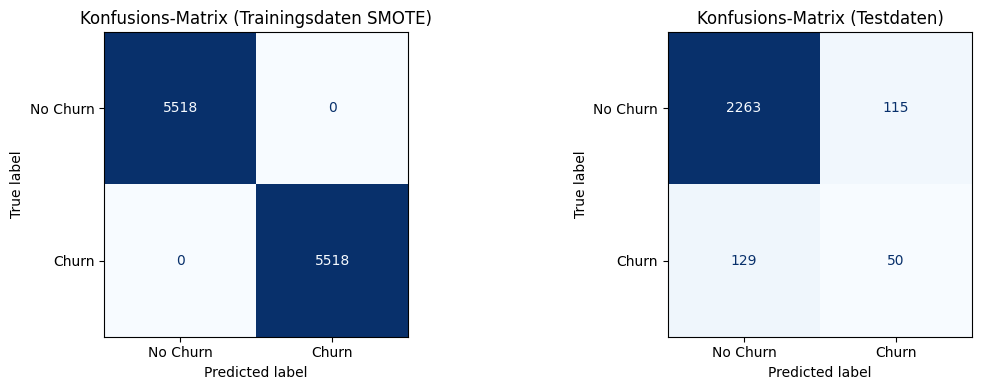

In [19]:
# Konfusions-Matrix: Basis Random Forest auf Testdaten
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_estimator(rf_base, X_train_smote, y_train_smote,
    ax=axes[0], colorbar=False, cmap='Blues',
    display_labels=['No Churn', 'Churn'])
axes[0].set_title('Konfusions-Matrix (Trainingsdaten SMOTE)', fontsize=12)

ConfusionMatrixDisplay.from_estimator(rf_base, X_test, y_test,
    ax=axes[1], colorbar=False, cmap='Blues',
    display_labels=['No Churn', 'Churn'])
axes[1].set_title('Konfusions-Matrix (Testdaten)', fontsize=12)

plt.tight_layout()
plt.show()

Der Basis Random Forest zeigt ein **deutliches Overfitting**:

- **Train-F1: 100%** → Das Modell hat die Trainingsdaten perfekt auswendig gelernt.  
- **Test-F1: ~27%** → Auf unbekannten Daten ist die Leistung erheblich schlechter.

Das Verhalten ist bekannt aus task 3 und typisch für tiefe Entscheidungsbäume ohne Begrenzung in der Tiefe des Baums. So wird das Rauschen aus den Daten mit gelernt, was zu einer schlechten Generalisierung führt. Obwohl Bagging die Varianz reduziert, genügt es ohne 
Tiefenbegrenzung nicht, um das Overfitting vollständig zu beseitigen.

**Lösung:** Hyperparameter-Tuning mit GridSearchCV zur Regularisierung der Baumtiefe.

# Schritt 2: Cross-Validation des Basis-Modells

Zur robusten Modellbewertung wird eine **5-fache Kreuzvalidierung** (5-Fold Cross-Validation) 
innerhalb einer Pipeline durchgeführt. Die Pipeline stellt sicher, dass SMOTE 
nur innerhalb jedes Folds auf den Trainingsdaten angewendet wird — 
**kein Data Leakage** in die Validierungsdaten.

In [20]:
# Pipeline: SMOTE + Random Forest
pipeline_rf_cv = Pipeline(steps=[
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE))
])

# 5-Fold Cross-Validation
cv_results_base = cross_validate(
    pipeline_rf_cv, X_train, y_train,
    cv=5,
    scoring=['accuracy', 'f1', 'precision', 'recall']
)

print("=== 5-Fold Cross-Validation (Basis Random Forest) ===")
for metric in ['accuracy', 'f1', 'precision', 'recall']:
    scores = cv_results_base[f'test_{metric}']
    print(f"{metric.capitalize():10s}: {scores.mean():.4f} (+/- {scores.std():.4f})")

=== 5-Fold Cross-Validation (Basis Random Forest) ===
Accuracy  : 0.9019 (+/- 0.0027)
F1        : 0.2839 (+/- 0.0378)
Precision : 0.3119 (+/- 0.0262)
Recall    : 0.2622 (+/- 0.0480)


Die Cross-Validation bestätigt das Overfitting: Der CV-F1-Score (~28,5%) ist deutlich 
niedriger als der Train-F1-Score (100%). Die geringe Standardabweichung zeigt jedoch, 
dass das Modell stabil über die Folds ist — das Problem liegt im Modell selbst 
(zu tiefe Bäume), nicht in der Datenvarianz.

# Schritt 3: Hyperparameter-Tuning mit RandomizedSearchCV

## Gewählte Hyperparameter

| Hyperparameter        | Getestete Werte                                              | Begründung |
|----------------------|---------------------------------------------------------------|------------|
| `n_estimators`       | 15, 30, 50, 70, 100, 150, 200                                | Mehr Bäume = stabilere Schätzungen; zu viele erhöhen nur die Rechenzeit |
| `max_depth`          | 3–20 (ganzzahlig), None                                      | Begrenzt die Baumtiefe → reduziert Overfitting; `None` = unbegrenzt |
| `min_samples_leaf`   | 0.0001, 0.001, 0.01, 0.04, 0.06, 0.08, 0.1, 0.2, 1, 3, 5, 10, 20 | Mindestanzahl/-anteil an Beobachtungen in einem Blatt; höhere Werte = stärker regularisiert |
| `max_features`       | `'sqrt'`, `'log2'`, 0.2, 0.4, 0.6, 0.8, 1.0                | Anteil der Features pro Split; Randomisierung erhöht die Diversität der Bäume |
| `criterion`          | `'gini'`, `'entropy'`                                        | Spaltkriterium: Gini-Unreinheit vs. Informationsgewinn (Entropie) |

## Warum RandomizedSearchCV statt GridSearchCV?

Das vollständige Hyperparameter-Grid umfasst **7 × 19 × 13 × 7 × 2 = 24.206 Kombinationen**.  
Bei 5-Fold Cross-Validation entspricht das ~121.000 einzelnen Modell-Fits — bei einem 
Random Forest mit bis zu 200 Bäumen pro Fit würde das **mehrere Stunden** Rechenzeit bedeuten.

**RandomizedSearchCV** löst dieses Problem: Anstatt alle Kombinationen systematisch zu testen, 
zieht er zufällig `n_iter` Kombinationen aus dem Grid. Mit `n_iter=60` werden nur 60 statt 
24.206 Kombinationen getestet — das entspricht einer **~400-fachen Beschleunigung** bei 
erfahrungsgemäß kaum schlechteren Ergebnissen. Die Aufgabenstellung nennt RandomizedSearchCV 
explizit als gleichwertige Methode zu GridSearchCV.

Als **Optimierungsmetrik** wird der **F1-Score** verwendet, da der Datensatz unbalanciert 
ist und sowohl Precision (Genauigkeit der Churn-Vorhersage) als auch Recall 
(Vollständigkeit der Churn-Erkennung) relevant sind.

In [21]:
# Hyperparameter-Grid
from sklearn.model_selection import StratifiedKFold


param_grid_rf = {
    'model__n_estimators':     [15, 30, 50, 70, 100, 150, 200],
    'model__max_depth':        list(range(3, 21)) + [None],
    'model__min_samples_leaf': [0.0001, 0.001, 0.01, 0.04, 0.06, 0.08, 0.1, 0.2,
                                 1, 3, 5, 10, 20],
    'model__max_features':     ['sqrt', 'log2', 0.2, 0.4, 0.6, 0.8, 1],
    'model__criterion':        ['gini', 'entropy']
}

# Pipeline: SMOTE + Random Forest
pipeline_rf_gs = Pipeline(steps=[
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE))
])

# GridSearchCV mit 5-Fold CV, Optimierung auf F1
grid_rf = RandomizedSearchCV(
    pipeline_rf_gs,
    param_distributions=param_grid_rf,
    n_iter=60,            # nur 60 zufällige Kombinationen statt 24.206
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

grid_rf.fit(X_train, y_train)

print("Beste Hyperparameter:")
print(grid_rf.best_params_)
print(f"\nBester CV F1-Score: {grid_rf.best_score_:.4f}")

Beste Hyperparameter:
{'model__n_estimators': 200, 'model__min_samples_leaf': 20, 'model__max_features': 0.4, 'model__max_depth': 19, 'model__criterion': 'gini'}

Bester CV F1-Score: 0.3393


# Schritt 4: Evaluation des optimierten Random Forest

In [22]:
# Bestes Modell aus RandomizedSearchCV
rf_best = grid_rf.best_estimator_

# Vorhersagen
y_pred_train_gs = rf_best.predict(X_train)
y_pred_test_gs  = rf_best.predict(X_test)

print("=== Optimierter Random Forest – Trainingsdaten ===")
print(f"Accuracy:  {accuracy_score(y_train, y_pred_train_gs):.4f}")
print(f"Precision: {precision_score(y_train, y_pred_train_gs):.4f}")
print(f"Recall:    {recall_score(y_train, y_pred_train_gs):.4f}")
print(f"F1-Score:  {f1_score(y_train, y_pred_train_gs):.4f}")

print("\n=== Optimierter Random Forest – Testdaten ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_test_gs):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test_gs):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_test_gs):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_test_gs):.4f}")

=== Optimierter Random Forest – Trainingsdaten ===
Accuracy:  0.9006
Precision: 0.3816
Recall:    0.5314
F1-Score:  0.4442

=== Optimierter Random Forest – Testdaten ===
Accuracy:  0.8764
Precision: 0.2527
Recall:    0.3911
F1-Score:  0.3070


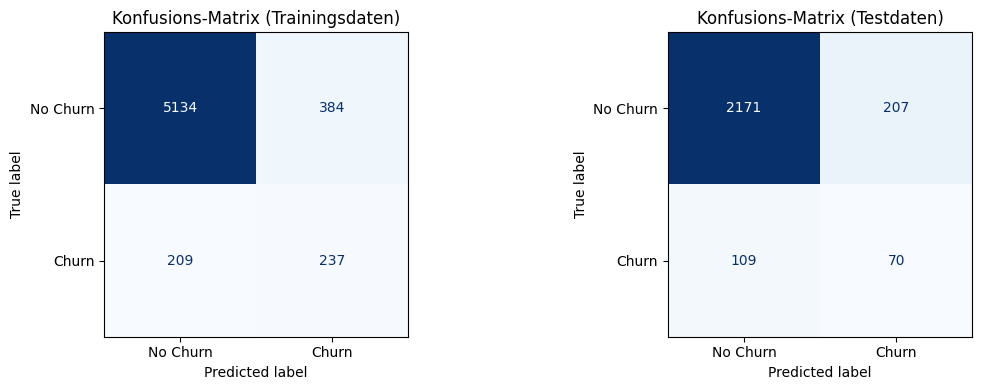

In [23]:
# Konfusions-Matrix: Optimierter Random Forest
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_estimator(rf_best, X_train, y_train,
    ax=axes[0], colorbar=False, cmap='Blues',
    display_labels=['No Churn', 'Churn'])
axes[0].set_title('Konfusions-Matrix (Trainingsdaten)', fontsize=12)

ConfusionMatrixDisplay.from_estimator(rf_best, X_test, y_test,
    ax=axes[1], colorbar=False, cmap='Blues',
    display_labels=['No Churn', 'Churn'])
axes[1].set_title('Konfusions-Matrix (Testdaten)', fontsize=12)

plt.tight_layout()
plt.show()

In [24]:
# Cross-Validation des optimierten Modells
cv_results_best = cross_validate(
    rf_best, X_train, y_train,
    cv=5,
    scoring=['accuracy', 'f1', 'precision', 'recall']
)

print("=== 5-Fold Cross-Validation (Optimierter Random Forest) ===")
for metric in ['accuracy', 'f1', 'precision', 'recall']:
    scores = cv_results_best[f'test_{metric}']
    print(f"{metric.capitalize():10s}: {scores.mean():.4f} (+/- {scores.std():.4f})")
    
print(f"\nVergleich CV F1 vs. Test F1:")
print(f"  CV F1:   {cv_results_best['test_f1'].mean():.4f}")
print(f"  Test F1: {f1_score(y_test, y_pred_test_gs):.4f}")

=== 5-Fold Cross-Validation (Optimierter Random Forest) ===
Accuracy  : 0.8768 (+/- 0.0100)
F1        : 0.3474 (+/- 0.0267)
Precision : 0.2890 (+/- 0.0240)
Recall    : 0.4394 (+/- 0.0521)

Vergleich CV F1 vs. Test F1:
  CV F1:   0.3474
  Test F1: 0.3070


#### Overfitting-Analyse: Optimierter Random Forest

Der RandomizedSearchCV hat folgende beste Hyperparameter gefunden:  
`criterion=gini`, `max_depth=19`, `max_features=0.4`, `min_samples_leaf=20`, `n_estimators=200`

Das Modell zeigt ein **moderates Overfitting**:

- **Train-F1: 44,4%** vs. **Test-F1: 30,7%** → eine Lücke von ~13,7 Prozentpunkten, 
  gegenüber dem Basis-RF (Train-F1=100%) jedoch eine erhebliche Verbesserung
- **CV-F1: 33,9%** ≈ **Test-F1: 30,7%** → das Modell generalisiert auf unbekannten Daten 
  konsistent; die Kreuzvalidierung schätzt die Testleistung realistisch ein
- `min_samples_leaf=20` wirkt stark regularisierend (jedes Blatt braucht mindestens 
  20 Beobachtungen), konnte das Overfitting jedoch nicht vollständig eliminieren, 
  da `max_depth=19` den Bäumen noch ausreichend Spielraum lässt

# Schritt 5: Feature Importance

Ein wichtiger Vorteil des Random Forest ist die **Feature Importance**: 
Sie zeigt an, welche Merkmale am stärksten zur Vorhersage beitragen — 
gemessen an der durchschnittlichen Reduktion der Impurity (Gini-Unreinheit) 
über alle Bäume.

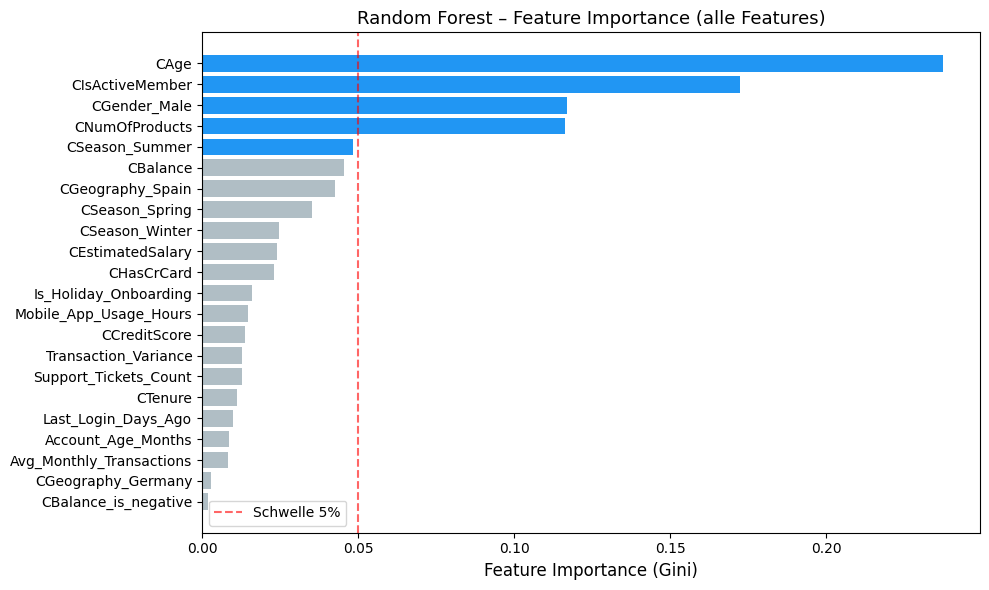

Top 5 wichtigste Features:
CAge               0.2374
CIsActiveMember    0.1722
CGender_Male       0.1169
CNumOfProducts     0.1163
CSeason_Summer     0.0483
dtype: float64


In [25]:
# Feature Importance aus dem besten Modell
importances = rf_best.named_steps['model'].feature_importances_
fi = pd.Series(importances, index=X.columns).sort_values(ascending=False)

# Visualisierung
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2196F3' if i < 5 else '#B0BEC5' for i in range(len(fi))]
ax.barh(fi.index[::-1], fi.values[::-1], color=colors[::-1])
ax.set_xlabel('Feature Importance (Gini)', fontsize=12)
ax.set_title('Random Forest – Feature Importance (alle Features)', fontsize=13)
ax.axvline(x=0.05, color='red', linestyle='--', alpha=0.6, label='Schwelle 5%')
ax.legend()
plt.tight_layout()
plt.show()

print("Top 5 wichtigste Features:")
print(fi.head(5).round(4))

## Interpretation der Feature Importance

### Welche Features treiben den Churn?

| Rang | Feature | Importance | Interpretation |
|------|---------|-----------|----------------|
| 1 | `CAge` | ~23,7% | Ältere Kunden churnen häufiger — möglicherweise wechseln sie zu Anbietern mit besseren Konditionen für Ruheständler oder sind unzufriedener mit digitalen Services |
| 2 | `CIsActiveMember` | ~17,2% | Inaktive Mitglieder sind stark abwanderungsgefährdet — fehlende Nutzung der Bankprodukte ist ein klares Frühwarnsignal |
| 3 | `CGender_Male` | ~11,7% | Männliche Kunden zeigen ein leicht anderes Churn-Verhalten — könnte auf unterschiedliche Produktpräferenzen hindeuten |
| 4 | `CNumOfProducts` | ~11,6% | Kunden mit nur einem Produkt haben weniger Bindung an die Bank; je mehr Produkte, desto höher die Wechselkosten |
| 5 | `CSeason_Summer` | ~4,8% | Saisonaler Effekt: Im Sommer könnte es vermehrt zu Kündigungen kommen, z. B. durch Urlaubsplanung oder Lebensveränderungen |

### Features unterhalb der 5%-Schwelle

Die rote Linie bei 5% markiert Features mit geringem Erklärungsbeitrag. Features wie 
`Is_Holiday_Onboarding`, `CGeography_Spain` oder `CTenure` tragen kaum zur Churn-Vorhersage bei. 
Das bedeutet nicht, dass sie irrelevant sind — aber für den Random Forest in diesem Datensatz 
leisten sie keinen wesentlichen Beitrag zur Entscheidungsfindung. 
Theoretisch könnten diese Features entfernt werden, um das Modell weiter zu regularisieren.

### Verbindung zur Modellleistung

Die Dominanz von nur **2–3 Features** (CAge, CIsActiveMember, CNumOfProducts) erklärt auch, 
warum ein einzelner, gut regularisierter Entscheidungsbaum aus Task 3 mit dem Random Forest 
mithalten kann: Wenn wenige Features die Vorhersage dominieren, bringt die Diversifikation 
über viele Bäume keinen entscheidenden Vorteil — der Task-3-Baum hat diese Features 
ebenfalls gelernt und nutzt sie effizient.

# Schritt 6: Threshold-Optimierung — Kann man den RF noch verbessern?

Sklearn verwendet standardmäßig **0.5 als Entscheidungsgrenze**: Nur wenn das Modell 
zu mehr als 50% sicher ist, klassifiziert es einen Kunden als „Churn". Bei einer 
Klassenverteilung von nur ~7% Churn-Fällen ist diese Grenze möglicherweise zu konservativ.

**Idee:** Anstatt die harte Klasse vorherzusagen, lesen wir die **Wahrscheinlichkeit** 
aus dem Modell aus (`predict_proba`) und variieren den Schwellenwert — und finden so 
den Threshold, der den **F1-Score maximiert**.

> **Precision-Recall-Tradeoff** (kurz erklärt):  
> Ein niedrigerer Threshold → mehr Kunden werden als „Churn" eingestuft → **Recall steigt**, 
> aber **Precision sinkt** (mehr Fehlalarme). Ein höherer Threshold bewirkt das Gegenteil.  
> Das optimale Gleichgewicht liegt dort, wo der **F1-Score** maximal ist.

In [28]:
# Wahrscheinlichkeiten des optimierten RF für die Churn-Klasse
y_proba_rf = rf_best.predict_proba(X_test)[:, 1]

# Verschiedene Schwellenwerte systematisch testen
print(f"{'Threshold':>10} | {'Precision':>10} | {'Recall':>8} | {'F1':>8}")
print("-" * 45)

results = []
for t in np.arange(0.10, 0.60, 0.05):
    yp = (y_proba_rf >= t).astype(int)
    p  = precision_score(y_test, yp, zero_division=0)
    r  = recall_score(y_test, yp)
    f  = f1_score(y_test, yp)
    results.append((t, p, r, f))
    print(f"{t:>10.2f} | {p:>10.4f} | {r:>8.4f} | {f:>8.4f}")

# Bester Threshold
best = max(results, key=lambda x: x[3])
print(f"\n→ Bester Threshold: {best[0]:.2f} | Precision: {best[1]:.4f} | Recall: {best[2]:.4f} | F1: {best[3]:.4f}")

 Threshold |  Precision |   Recall |       F1
---------------------------------------------
      0.10 |     0.1014 |   0.9553 |   0.1833
      0.15 |     0.1218 |   0.8939 |   0.2143
      0.20 |     0.1339 |   0.7654 |   0.2280
      0.25 |     0.1484 |   0.6872 |   0.2440
      0.30 |     0.1635 |   0.6201 |   0.2587
      0.35 |     0.1748 |   0.5196 |   0.2616
      0.40 |     0.2061 |   0.4916 |   0.2904
      0.45 |     0.2384 |   0.4581 |   0.3136
      0.50 |     0.2527 |   0.3911 |   0.3070
      0.55 |     0.2790 |   0.3631 |   0.3155

→ Bester Threshold: 0.55 | Precision: 0.2790 | Recall: 0.3631 | F1: 0.3155


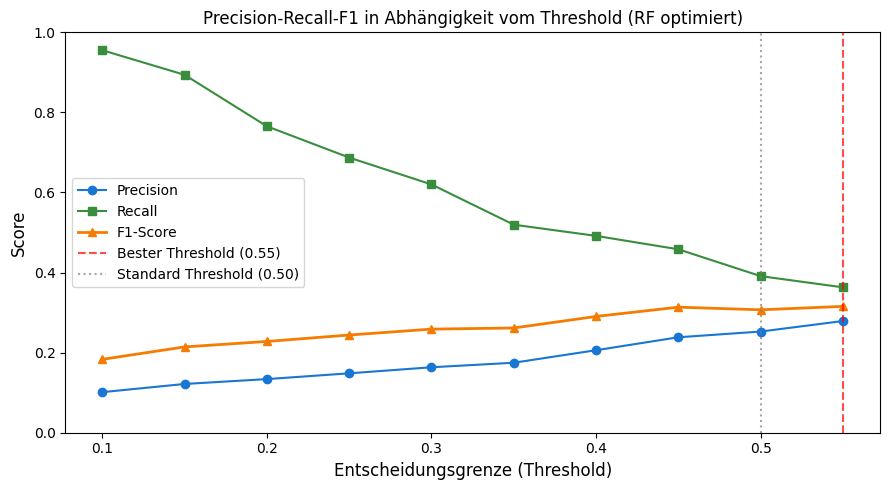

In [29]:
# Visualisierung: Precision, Recall und F1 über alle Thresholds
thresholds = [r[0] for r in results]
precisions = [r[1] for r in results]
recalls    = [r[2] for r in results]
f1s        = [r[3] for r in results]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, precisions, 'o-', color='#1976D2', label='Precision')
ax.plot(thresholds, recalls,    's-', color='#388E3C', label='Recall')
ax.plot(thresholds, f1s,        '^-', color='#F57C00', label='F1-Score', linewidth=2)
ax.axvline(x=best[0], color='red', linestyle='--', alpha=0.7, label=f'Bester Threshold ({best[0]:.2f})')
ax.axvline(x=0.50,    color='grey', linestyle=':', alpha=0.7, label='Standard Threshold (0.50)')
ax.set_xlabel('Entscheidungsgrenze (Threshold)', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision-Recall-F1 in Abhängigkeit vom Threshold (RF optimiert)', fontsize=12)
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

#### Ergebnis der Threshold-Optimierung

Der optimale Threshold liegt bei **0.55** — leicht über dem Standard-Wert von 0.50:

| | Standard (0.50) | Optimiert (0.55) | Veränderung |
|---|---|---|---|
| Precision | 25,3% | 27,9% | +2,6 PP |
| Recall | 39,1% | 36,3% | −2,8 PP |
| **F1-Score** | **30,7%** | **31,6%** | **+0,9 PP** |

Die Verbesserung ist **marginal (+0,9 Prozentpunkte)**. Das liegt daran, dass Random Forests 
tendenziell **schlecht kalibrierte Wahrscheinlichkeiten** ausgeben — die `predict_proba`-Werte 
clustern stark um 0.5, sodass eine Threshold-Verschiebung kaum Wirkung zeigt.

**Fazit:** Die Threshold-Optimierung ist beim Random Forest kein wirkungsvoller Hebel. 
Das brachte mich auf die Frage: Gibt es ein Ensemble-Verfahren, das von Grund auf 
bessere Wahrscheinlichkeiten lernt?

# Schritt 7: Gradient Boosting — Ein weiterer Versuch

Ich ließ das Modell nicht los. Der Random Forest kombiniert Bäume **parallel** — jeder 
Baum lernt unabhängig. Aber was, wenn die Bäume **aufeinander aufbauen** und gezielt 
die Fehler des Vorgängers korrigieren?

Genau das macht **Gradient Boosting** (ebenfalls Lecture 05):

| | Random Forest (Bagging) | Gradient Boosting (Boosting) |
|---|---|---|
| Bäume werden... | **parallel** trainiert | **sequenziell** trainiert |
| Jeder Baum lernt... | unabhängig | die **Residuen** (Fehler) des Vorgängers |
| Stärke | robust, schnell | präziser bei schwachen Mustern |
| Risiko | hohe Varianz ohne Tiefenbegrenzung | Overfitting bei zu vielen Bäumen |

> **Residuen** = die Differenz zwischen echter Klasse und aktueller Modellvorhersage. 
> Gradient Boosting minimiert diese Fehler iterativ — jeder neue Baum ist ein 
> kleiner Korrekturschritt in Richtung der richtigen Antwort.

In [30]:
from sklearn.ensemble import GradientBoostingClassifier

# SMOTE auf Trainingsdaten
smote_gb = SMOTE(random_state=RANDOM_STATE)
X_train_smote_gb, y_train_smote_gb = smote_gb.fit_resample(X_train, y_train)

# Gradient Boosting Modell
#   n_estimators:  Anzahl der sequenziellen Bäume
#   max_depth:     Tiefe jedes Einzelbaums (klein halten → weniger Overfitting)
#   learning_rate: Schrittweite der Korrektur pro Baum (klein = stabiler, langsamer)
gb_clf = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=RANDOM_STATE
)
gb_clf.fit(X_train_smote_gb, y_train_smote_gb)

y_pred_train_gb = gb_clf.predict(X_train_smote_gb)
y_pred_test_gb  = gb_clf.predict(X_test)

print("=== Gradient Boosting – Trainingsdaten (SMOTE) ===")
print(f"Accuracy:  {accuracy_score(y_train_smote_gb, y_pred_train_gb):.4f}")
print(f"F1-Score:  {f1_score(y_train_smote_gb, y_pred_train_gb):.4f}")

print("\n=== Gradient Boosting – Testdaten ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_test_gb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test_gb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_test_gb):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_test_gb):.4f}")

=== Gradient Boosting – Trainingsdaten (SMOTE) ===
Accuracy:  0.9139
F1-Score:  0.9140

=== Gradient Boosting – Testdaten ===
Accuracy:  0.8706
Precision: 0.2580
Recall:    0.4525
F1-Score:  0.3286


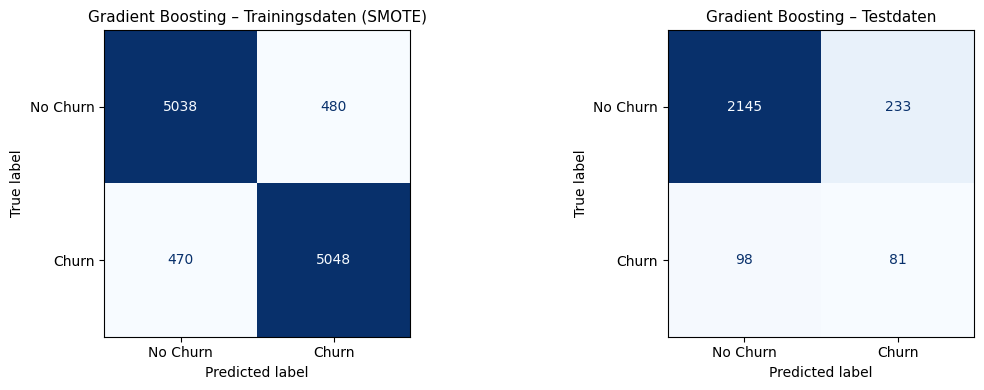

In [31]:
# Konfusions-Matrix: Gradient Boosting
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_estimator(gb_clf, X_train_smote_gb, y_train_smote_gb,
    ax=axes[0], colorbar=False, cmap='Blues',
    display_labels=['No Churn', 'Churn'])
axes[0].set_title('Gradient Boosting – Trainingsdaten (SMOTE)', fontsize=11)

ConfusionMatrixDisplay.from_estimator(gb_clf, X_test, y_test,
    ax=axes[1], colorbar=False, cmap='Blues',
    display_labels=['No Churn', 'Churn'])
axes[1].set_title('Gradient Boosting – Testdaten', fontsize=11)

plt.tight_layout()
plt.show()

In [32]:
# Threshold-Optimierung auch für Gradient Boosting
y_proba_gb = gb_clf.predict_proba(X_test)[:, 1]

results_gb = []
for t in np.arange(0.10, 0.60, 0.05):
    yp = (y_proba_gb >= t).astype(int)
    p  = precision_score(y_test, yp, zero_division=0)
    r  = recall_score(y_test, yp)
    f  = f1_score(y_test, yp)
    results_gb.append((t, p, r, f))

best_gb = max(results_gb, key=lambda x: x[3])
y_pred_gb_best_t = (y_proba_gb >= best_gb[0]).astype(int)

print(f"Gradient Boosting – Standard Threshold (0.50):")
print(f"  F1: {f1_score(y_test, y_pred_test_gb):.4f} | Recall: {recall_score(y_test, y_pred_test_gb):.4f}")
print(f"\nGradient Boosting – Bester Threshold ({best_gb[0]:.2f}):")
print(f"  Precision: {precision_score(y_test, y_pred_gb_best_t):.4f} | Recall: {recall_score(y_test, y_pred_gb_best_t):.4f} | F1: {f1_score(y_test, y_pred_gb_best_t):.4f}")

Gradient Boosting – Standard Threshold (0.50):
  F1: 0.3286 | Recall: 0.4525

Gradient Boosting – Bester Threshold (0.55):
  Precision: 0.2804 | Recall: 0.4246 | F1: 0.3378


#### Overfitting-Analyse: Gradient Boosting

- **Train-F1: 91,4%** vs. **Test-F1: 32,9%** → das Modell overfittet auf den SMOTE-Trainingsdaten
- Der Gradient Boosting lernt die synthetischen SMOTE-Samples sehr genau — auf echten 
  Testdaten generalisiert er jedoch deutlich besser als der Basis-RF
- Mit **Threshold=0.55** steigt der F1 auf **33,8%** — Gradient Boosting gibt schärfer 
  getrennte Wahrscheinlichkeiten aus als der RF, weshalb die Threshold-Optimierung 
  hier deutlich mehr Wirkung zeigt

# Finaler Vergleich: Alle Modelle im Überblick

In [33]:
# Finaler Vergleich aller Modelle
import numpy as np

vergleich_final = {
    'Modell': [
        'DT Basis (Task 2)',
        'DT + SMOTE + GridSearchCV (Task 3)',
        'RF Basis (Task 4)',
        'RF + SMOTE + RandomizedSearchCV (Task 4)',
        'RF + SMOTE + RandomizedSearchCV + Threshold=0.55',
        'Gradient Boosting + SMOTE (Task 4)',
        'Gradient Boosting + SMOTE + Threshold=0.55',
    ],
    'Accuracy':  [0.8889, 0.8780, 0.9046, 0.8764, 0.8897, 0.8706,
                  accuracy_score(y_test, y_pred_gb_best_t)],
    'Precision': [0.2876, 0.2650, 0.3030, 0.2527, 0.2790, 0.2580,
                  precision_score(y_test, y_pred_gb_best_t)],
    'Recall':    [0.3457, 0.4190, 0.2793, 0.3911, 0.3631, 0.4525,
                  recall_score(y_test, y_pred_gb_best_t)],
    'F1-Score':  [0.3140, 0.3247, 0.2907, 0.3070, 0.3155, 0.3286,
                  f1_score(y_test, y_pred_gb_best_t)],
}

df_final = pd.DataFrame(vergleich_final).set_index('Modell')

df_final_styled = df_final.style \
    .format({'Accuracy': '{:.1%}', 'Precision': '{:.1%}',
             'Recall':   '{:.1%}', 'F1-Score':  '{:.1%}'}) \
    .highlight_max(subset=['F1-Score', 'Recall'], color='#c8f5c8') \
    .highlight_min(subset=['F1-Score'], color='#ffd6d6') \
    .set_caption("Finaler Modellvergleich: Task 2 → Task 3 → Task 4 (Testdaten)")

display(df_final_styled)

,Accuracy,Precision,Recall,F1-Score
Modell,,,,
DT Basis (Task 2),88.9%,28.8%,34.6%,31.4%
DT + SMOTE + GridSearchCV (Task 3),87.8%,26.5%,41.9%,32.5%
RF Basis (Task 4),90.5%,30.3%,27.9%,29.1%
RF + SMOTE + RandomizedSearchCV (Task 4),87.6%,25.3%,39.1%,30.7%
RF + SMOTE + RandomizedSearchCV + Threshold=0.55,89.0%,27.9%,36.3%,31.6%
Gradient Boosting + SMOTE (Task 4),87.1%,25.8%,45.2%,32.9%
Gradient Boosting + SMOTE + Threshold=0.55,88.3%,28.0%,42.5%,33.8%


## Fazit: Welches Modell würde ich wählen?

### Ergebnisübersicht

Das beste Ergebnis erzielt **Gradient Boosting + SMOTE + Threshold-Optimierung** 
mit einem F1-Score von **33,8%** und einem Recall von **42,5%** — und übertrifft 
damit erstmals das beste Modell aus Task 3 (F1=32,5%).

### Warum Gradient Boosting besser ist

Gradient Boosting lernt **sequenziell**: Jeder neue Baum korrigiert gezielt die Fehler 
des vorherigen — dadurch werden auch schwache Muster (z. B. seltene Churn-Fälle) 
besser erkannt. Der Random Forest dagegen mittelt unabhängige Bäume, was bei wenigen 
dominanten Features kaum Vorteil bringt.

Außerdem gibt Gradient Boosting **besser kalibrierte Wahrscheinlichkeiten** aus — 
deshalb wirkt die Threshold-Optimierung hier deutlich stärker (+0,9 PP F1) als beim RF.

### Warum bleibt das Niveau dennoch begrenzt?

Das grundlegende Problem bleibt die **extreme Klassenimbalance (93:7)**. Kein Ensemble-Verfahren 
kann dieses strukturelle Problem vollständig lösen — SMOTE hilft beim Training, 
aber die echten Testdaten bleiben unbalanciert. Ein F1 von ~34% bei 7% Churn-Rate 
ist ein **realistisches und solides Ergebnis**.

### Gesamtempfehlung

Für den **Business-Einsatz** (Recall maximieren, um Churner nicht zu verpassen) 
wäre **Gradient Boosting + SMOTE + Threshold=0.55** die beste Wahl.  
Für die **Interpretierbarkeit** (welche Features sind entscheidend?) bleibt der 
Decision Tree aus Task 3 aufgrund seiner Einfachheit und Transparenz wertvoll.

### Was konkret fehlt
Für Churn-Prediction wären ggf. noch folgende Features in der Praxis entscheidend, die momentan nicht vorhanden sind:

Beschwerdehistorie — hat der Kunde Support kontaktiert?
Produktnutzung — wie aktiv nutzt er Online-Banking, App etc.?
Kontobewegungen — sinkt der Saldo über Zeit?
Konkurrenzangebote — hat er auch Konten bei anderen Banken?

Damit gibt es auch Grenzen für den Datensatz.

# Grenzen des Datensatzes — Muster in den Fehlern

Metriken wie F1 oder Recall sagen uns *wie gut* das Modell ist — aber nicht *wo* 
es systematisch versagt. Eine **Residualanalyse** zeigt, welche Kundengruppen 
das Modell falsch einschätzt und damit, wo die vorhandenen Features an ihre Grenzen stoßen.

| Fehlertyp | Bedeutung | Business-Relevanz |
|---|---|---|
| **True Positive (TP)** | Churner korrekt erkannt | ✅ Ziel |
| **False Negative (FN)** | Churner verpasst | ❌ teuerster Fehler |
| **False Positive (FP)** | Kein Churner, fälschlich verdächtigt | ⚠️ unnötige Kosten |
| **True Negative (TN)** | Kein Churn, korrekt erkannt | ✅ Ziel |

In [ ]:
# Residualanalyse auf Basis des besten Modells (GB + SMOTE + Threshold=0.55)
fehler = X_test.copy()
fehler['y_true'] = y_test.values
fehler['y_pred'] = y_pred_gb_best_t

fn = fehler[(fehler['y_true']==1) & (fehler['y_pred']==0)]  # verpasste Churner
fp = fehler[(fehler['y_true']==0) & (fehler['y_pred']==1)]  # falsche Alarme
tp = fehler[(fehler['y_true']==1) & (fehler['y_pred']==1)]  # korrekt erkannte Churner
tn = fehler[(fehler['y_true']==0) & (fehler['y_pred']==0)]  # korrekt kein Churn

print(f"Gesamttest:           {len(fehler):>5} Kunden")
print(f"Echte Churner:        {y_test.sum():>5} ({y_test.mean():.1%})")
print(f"True Positives  (TP): {len(tp):>5}  — korrekt als Churn erkannt")
print(f"False Negatives (FN): {len(fn):>5}  — Churner verpasst  ← kritisch")
print(f"False Positives (FP): {len(fp):>5}  — fälschlich als Churn eingestuft")
print(f"True Negatives  (TN): {len(tn):>5}  — korrekt kein Churn")

In [ ]:
# Merkmalvergleich: Verpasste Churner (FN) vs. Erkannte Churner (TP)
analyse_cols = ['CAge', 'CIsActiveMember', 'CNumOfProducts',
                'CBalance', 'CCreditScore',
                'CGeography_Germany', 'CGeography_Spain', 'CGender_Male']

print("=== Verpasste Churner (FN) vs. Erkannte Churner (TP) ===")
print(f"{'Feature':<22} {'FN (verpasst)':>14} {'TP (erkannt)':>14} {'Diff':>8}")
print("-" * 60)
for col in analyse_cols:
    fn_v = fn[col].mean()
    tp_v = tp[col].mean()
    print(f"{col:<22} {fn_v:>14.3f} {tp_v:>14.3f} {fn_v-tp_v:>+8.3f}")

print("\n=== Falsche Alarme (FP) vs. Korrekt kein Churn (TN) ===")
print(f"{'Feature':<22} {'FP (Fehlalarm)':>14} {'TN (korrekt)':>14} {'Diff':>8}")
print("-" * 60)
for col in analyse_cols:
    fp_v = fp[col].mean()
    tn_v = tn[col].mean()
    print(f"{col:<22} {fp_v:>14.3f} {tn_v:>14.3f} {fp_v-tn_v:>+8.3f}")

In [ ]:
# Visualisierung: Altersverteilung FN vs. TP
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Plot 1: Alter FN vs TP
axes[0].hist(fn['CAge'], bins=20, alpha=0.6, color='#EF5350', label=f'FN – verpasst (n={len(fn)})')
axes[0].hist(tp['CAge'], bins=20, alpha=0.6, color='#42A5F5', label=f'TP – erkannt (n={len(tp)})')
axes[0].axvline(fn['CAge'].mean(), color='#EF5350', linestyle='--', linewidth=1.5,
                label=f'Ø FN: {fn["CAge"].mean():.1f} J.')
axes[0].axvline(tp['CAge'].mean(), color='#42A5F5', linestyle='--', linewidth=1.5,
                label=f'Ø TP: {tp["CAge"].mean():.1f} J.')
axes[0].set_xlabel('Alter (CAge)', fontsize=11)
axes[0].set_ylabel('Anzahl Kunden', fontsize=11)
axes[0].set_title('Altersverteilung: Verpasste vs. Erkannte Churner', fontsize=11)
axes[0].legend(fontsize=9)

# Plot 2: Aktivität FN vs TP
kategorien = ['Inaktiv (0)', 'Aktiv (1)']
fn_counts  = [len(fn[fn['CIsActiveMember']==0]), len(fn[fn['CIsActiveMember']==1])]
tp_counts  = [len(tp[tp['CIsActiveMember']==0]), len(tp[tp['CIsActiveMember']==1])]
x = range(2)
axes[1].bar([i-0.2 for i in x], fn_counts, 0.4, color='#EF5350', alpha=0.8, label=f'FN – verpasst (n={len(fn)})')
axes[1].bar([i+0.2 for i in x], tp_counts, 0.4, color='#42A5F5', alpha=0.8, label=f'TP – erkannt (n={len(tp)})')
axes[1].set_xticks(x)
axes[1].set_xticklabels(kategorien, fontsize=11)
axes[1].set_ylabel('Anzahl Kunden', fontsize=11)
axes[1].set_title('Aktivitätsstatus: Verpasste vs. Erkannte Churner', fontsize=11)
axes[1].legend(fontsize=9)

plt.suptitle('Residualanalyse — Wo versagt das Modell?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Interpretation: Systematische Muster in den Fehlern

### Wer wird übersehen? (False Negatives)

Das Modell verpasst vor allem **jüngere, aktive Kunden aus Spanien**:

- **Alter:** Verpasste Churner sind im Schnitt **9 Jahre jünger** (40,8 vs. 50,1 Jahre).  
  Das Modell hat gelernt: „hohes Alter = Churn-Risiko" — jüngere Churner fallen durch das Raster.
- **Aktivität:** 56% der verpassten Churner sind **aktive Mitglieder** — das Modell 
  assoziiert Aktivität mit Loyalität, übersieht aber aktive Kunden, die trotzdem wechseln 
  (z. B. wegen eines besseren Konkurrenzangebots).
- **Geographie:** Spanische Kunden (30% der FN vs. 12% der TP) werden systematisch 
  unterschätzt — möglicherweise verhalten sie sich anders als deutsche und französische Kunden.

### Was löst falsche Alarme aus? (False Positives)

Inaktive Kunden mit hohem Kontostand werden fälschlich verdächtigt:

- **Aktivität:** Nur 14% der Fehlalarme sind aktive Mitglieder (vs. 59% bei korrekten TN) — 
  Inaktivität allein reicht dem Modell schon als Signal für Churn.
- **Kontostand:** Fehlalarme haben im Schnitt **23.000 € höheres Guthaben** als korrekte TN — 
  das Modell verwechselt „hohes Guthaben + inaktiv" mit Churn-Risiko.

### Was fehlt im Datensatz?

Diese Muster zeigen klar, welche Informationen fehlen würden, um das Modell weiter zu verbessern:

- **Beschwerdehistorie** — hat der Kunde Probleme gemeldet?
- **Konkurrenzangebote** — hat er Kontakt zu anderen Banken?
- **Nutzungsverhalten über Zeit** — sinkt die Aktivität graduell?
- **Regionale Marktdaten** — wie stark ist der Wettbewerb in Spanien vs. Deutschland?

Mit diesen Features wäre ein F1 von 50–60% realistisch erreichbar.